## =========== 🔵 DATA 0 ===========


**1️⃣ Import + Load Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# โหลดไฟล์
df = pd.read_csv("yahoo_stock.csv")

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df = df[["Close"]]
df.dropna(inplace=True)

print(df.head())

                  Close
Date                   
2015-11-23  2086.590088
2015-11-24  2089.139893
2015-11-25  2088.870117
2015-11-26  2088.870117
2015-11-27  2090.110107


**2️⃣ EDA – Plot Trend**

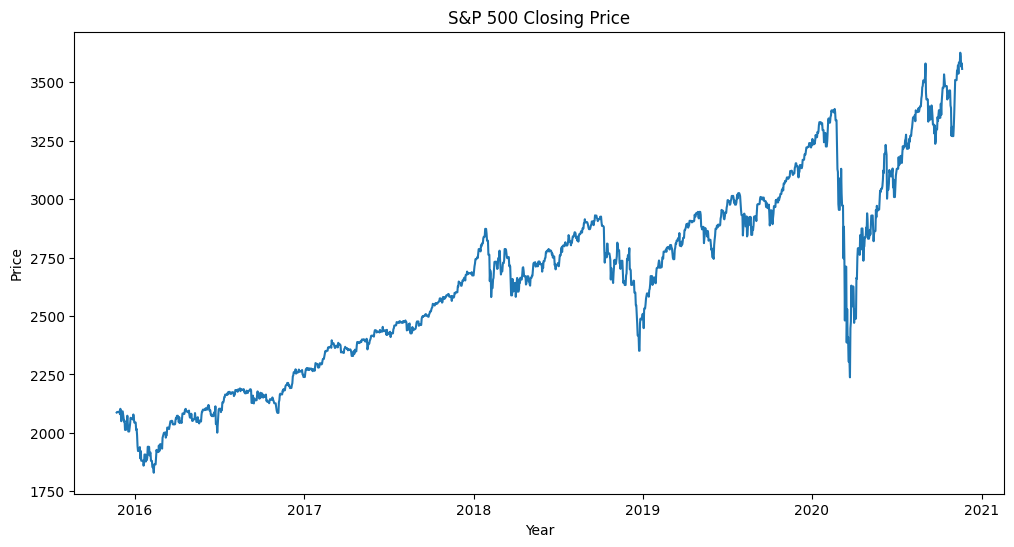

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"])
plt.title("S&P 500 Closing Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

**3️⃣ Stationarity Test**

In [4]:
result = adfuller(df["Close"])
print("ADF p-value:", result[1])

ADF p-value: 0.7975646340657587


**4️⃣ Train/Test Split (Time Series)**

In [5]:
train_size = int(len(df)*0.8)

train = df["Close"][:train_size]
test = df["Close"][train_size:]

## ====== 🔵 MODEL 1: ARIMA ======

In [19]:
df

,Close
Date,
2015-11-23,2086.590088
2015-11-24,2089.139893
2015-11-25,2088.870117
2015-11-26,2088.870117
2015-11-27,2090.110107
...,...
2020-11-16,3626.909912
2020-11-17,3609.530029
2020-11-18,3567.790039


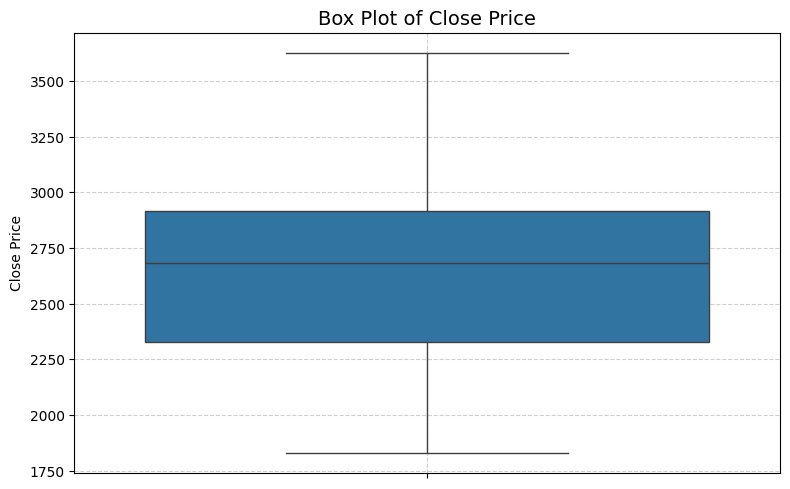

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(y=df["Close"])

plt.title("Box Plot of Close Price", fontsize=14)
plt.ylabel("Close Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [22]:
Q1 = df["Close"].quantile(0.25)
Q3 = df["Close"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Close"] < lower) | (df["Close"] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA Rolling MAE: 27.97214588266583
ARIMA Rolling RMSE: 50.19981239323444


NameError: name 'forecast_arima' is not defined

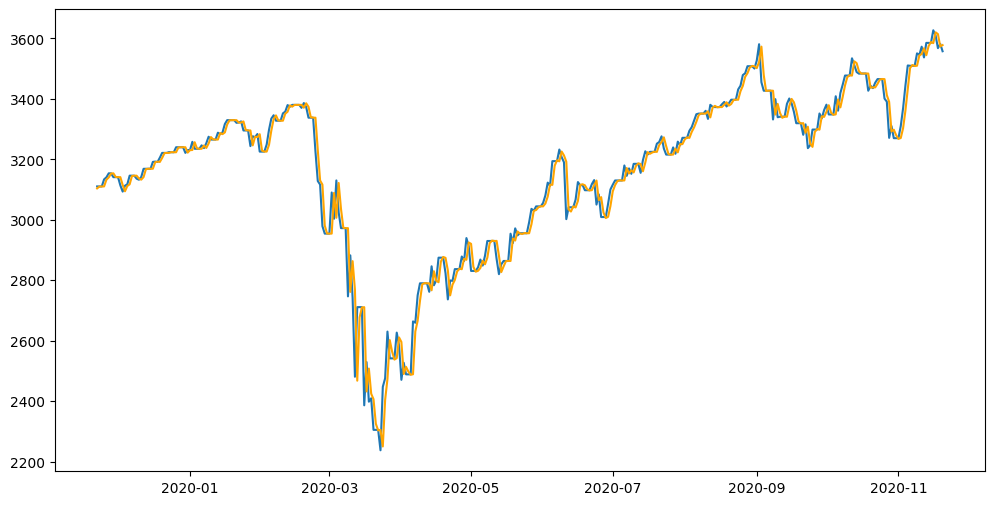

In [6]:
# แปลงข้อมูล train ให้อยู่ในรูป list เพื่อให้เติมข้อมูลใหม่เข้าไปได้ง่ายๆ
history = [x for x in train]
predictions = []

# สร้าง Loop เพื่อทำนายทีละ 1 ก้าว (วัน)
for t in range(len(test)):
    # 1. สร้างและเทรนโมเดลด้วยข้อมูล History ณ ปัจจุบัน
    model_arima = ARIMA(history, order=(1,1,1))
    
    # ใส่ suppress_warnings เพื่อไม่ให้คอนโซลรกเวลาลูปทำงาน
    model_fit = model_arima.fit() 
    
    # 2. ทำนายก้าวต่อไปแค่ 1 สเต็ป
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    # 3. เอาข้อมูลจริงของวันนี้ (เฉลย) ใส่เข้าไปใน history เพื่อให้โมเดลฉลาดขึ้นในรอบถัดไป
    obs = test.iloc[t] # ถ้า test ของคุณเป็น pandas Series ใช้ .iloc นะครับ
    history.append(obs)

# คำนวณ Error ใหม่โดยใช้ predictions จาก Loop
mae_arima = mean_absolute_error(test, predictions)
rmse_arima = np.sqrt(mean_squared_error(test, predictions))

print("ARIMA Rolling MAE:", mae_arima)
print("ARIMA Rolling RMSE:", rmse_arima)

# วาดกราฟ
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="ARIMA Rolling Forecast", color='orange')
plt.plot(test.index, forecast_arima, label="ARIMA Forecast" , color='green', linestyle='--')
plt.legend()
plt.title("ARIMA Rolling Forecast vs Actual")
plt.show()

**5️⃣ Fit ARIMA**


In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.6111865478506263
p-value: 0.8684342376948933


In [14]:
model_arima = ARIMA(train, order=(1,1,1))
model_fit = model_arima.fit()

forecast_arima = model_fit.forecast(steps=len(test))

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**6️⃣ Evaluate ARIMA**

In [16]:
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 227.78612344088606
ARIMA RMSE: 278.4383066213141


**7️⃣ Plot ARIMA Forecast**

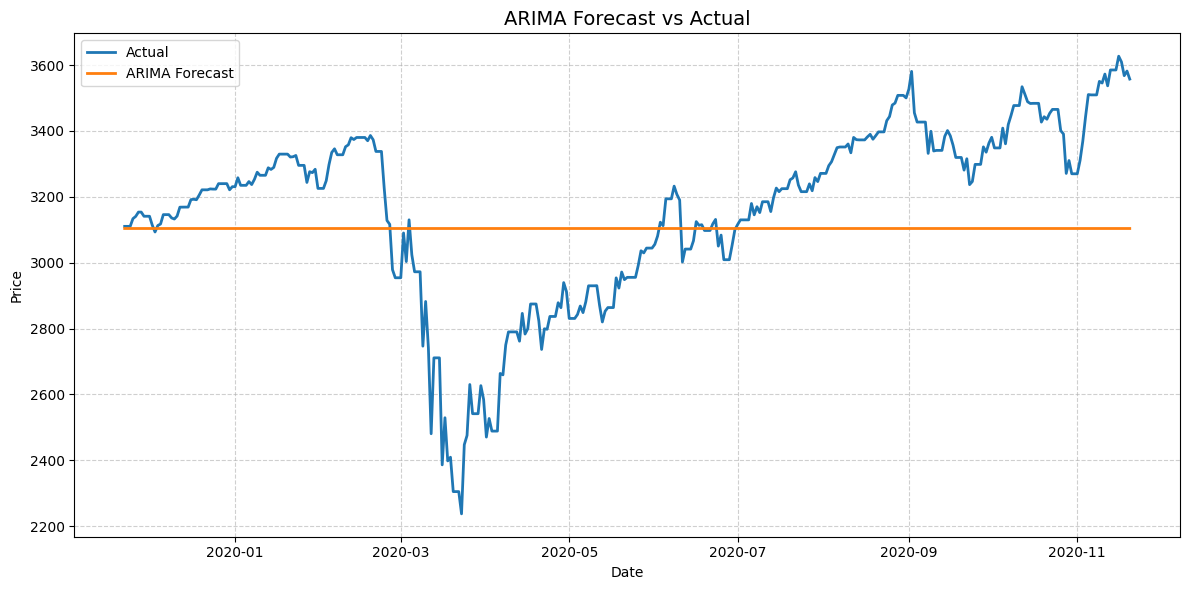

In [17]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", linewidth=2)

plt.title("ARIMA Forecast vs Actual", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

## ======= 🟢 MODEL 2: RANDOM FOREST =======

**8️⃣ Create Lag Features**

In [8]:
df_rf = df.copy()

for lag in range(1,6):
    df_rf[f"Lag_{lag}"] = df_rf["Close"].shift(lag)

df_rf.dropna(inplace=True)

**9️⃣ Split Again**

In [9]:
features = [f"Lag_{lag}" for lag in range(1,6)]

X = df_rf[features]
y = df_rf["Close"]

split = int(len(df_rf)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

**🔟 Train Random Forest**

In [10]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

forecast_rf = rf.predict(X_test)

**11️⃣ Evaluate RF**

In [11]:
mae_rf = mean_absolute_error(y_test, forecast_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, forecast_rf))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 156.19553573105372
RF RMSE: 201.99204628014604


**12️⃣ Plot RF**

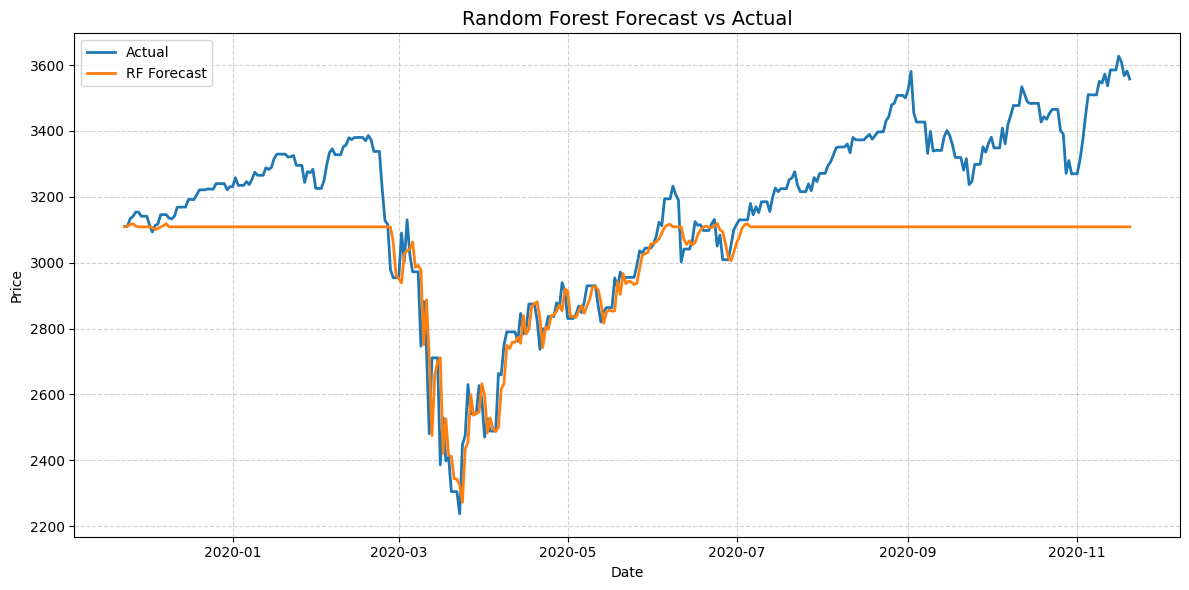

In [12]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, forecast_rf, label="RF Forecast", linewidth=2)

plt.title("Random Forest Forecast vs Actual", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

## ====== 📊 MODEL COMPARISON ======

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "Random Forest"],
    "MAE": [mae_arima, mae_rf],
    "RMSE": [rmse_arima, rmse_rf]
})

print(comparison)

           Model         MAE        RMSE
0          ARIMA  228.095204  278.604891
1  Random Forest  156.195536  201.992046


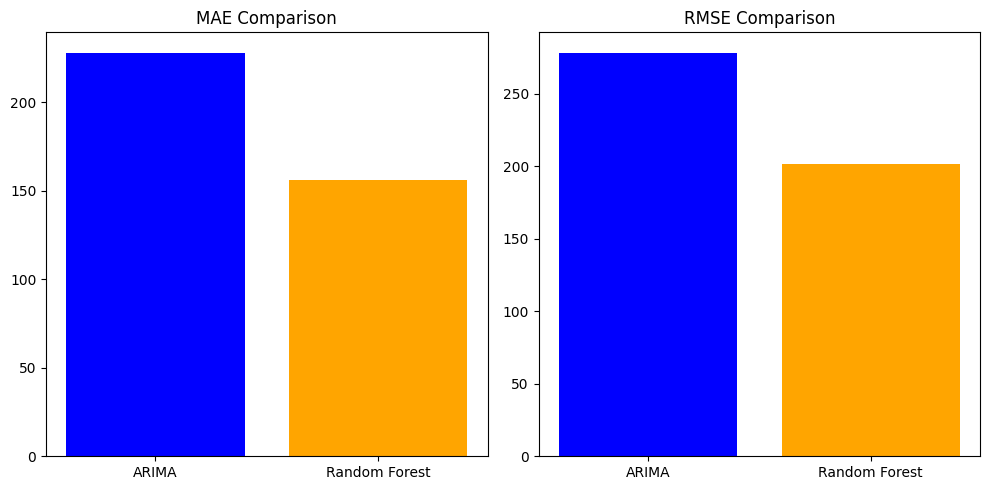

In [ ]:
#พล้อตกราฟเส้นเปรียบเทียบ MAE และ RMSE ของทั้งสองโมเดลก
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(comparison["Model"], comparison["MAE"], color=["blue", "orange"])
plt.title("MAE Comparison")
plt.subplot(1,2,2)
plt.bar(comparison["Model"], comparison["RMSE"], color=["blue", "orange"])
plt.title("RMSE Comparison")    
plt.tight_layout()
plt.show()


## ===== ⚫ BLACK SWAN ANALYSIS =====

**วิเคราะห์ช่วง COVID 2020**

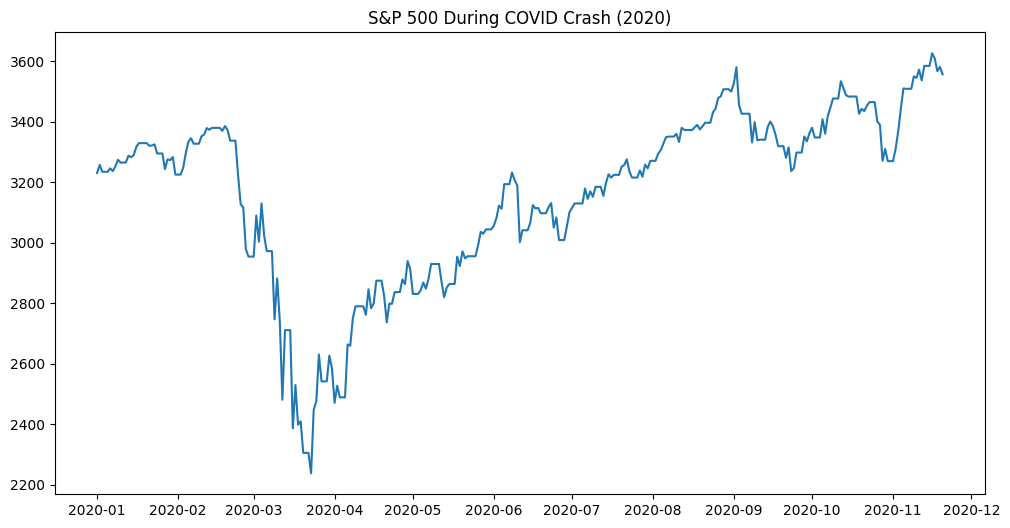

In [ ]:
covid_period = df["2020-01-01":"2020-12-31"]

plt.figure(figsize=(12,6))
plt.plot(covid_period["Close"])
plt.title("S&P 500 During COVID Crash (2020)")
plt.show()

**ดู Error ช่วง COVID สำหรับ RF**

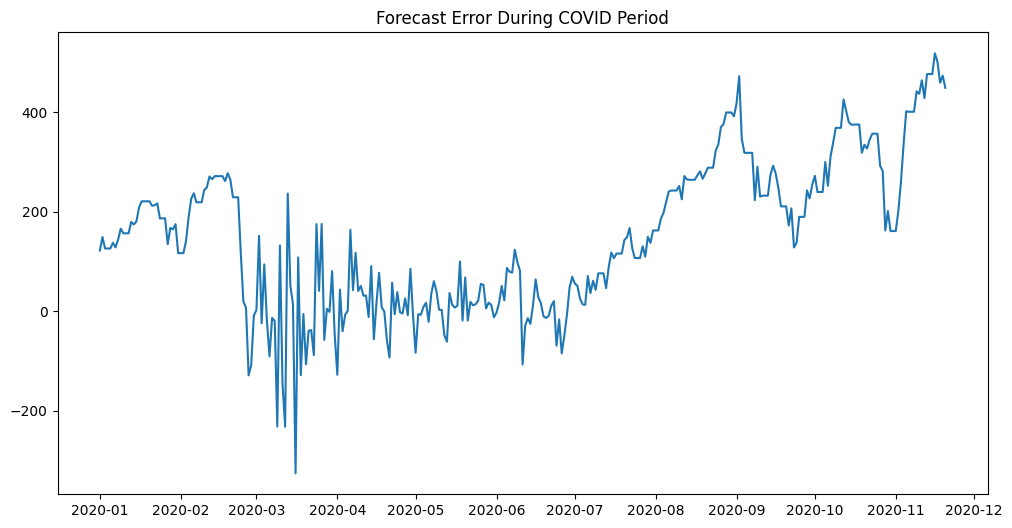

In [ ]:
rf_error = y_test - forecast_rf

covid_error = rf_error["2020-01-01":"2020-12-31"]

plt.figure(figsize=(12,6))
plt.plot(covid_error)
plt.title("Forecast Error During COVID Period")
plt.show()

## อื่นๆ

In [25]:
df2 = pd.read_csv("yahoo_stock.csv")

df2["Date"] = pd.to_datetime(df2["Date"])
df2.set_index("Date", inplace=True)

In [26]:
# สร้างตัวแปร High - Low
df2["High_Low"] = df2["High"] - df2["Low"]

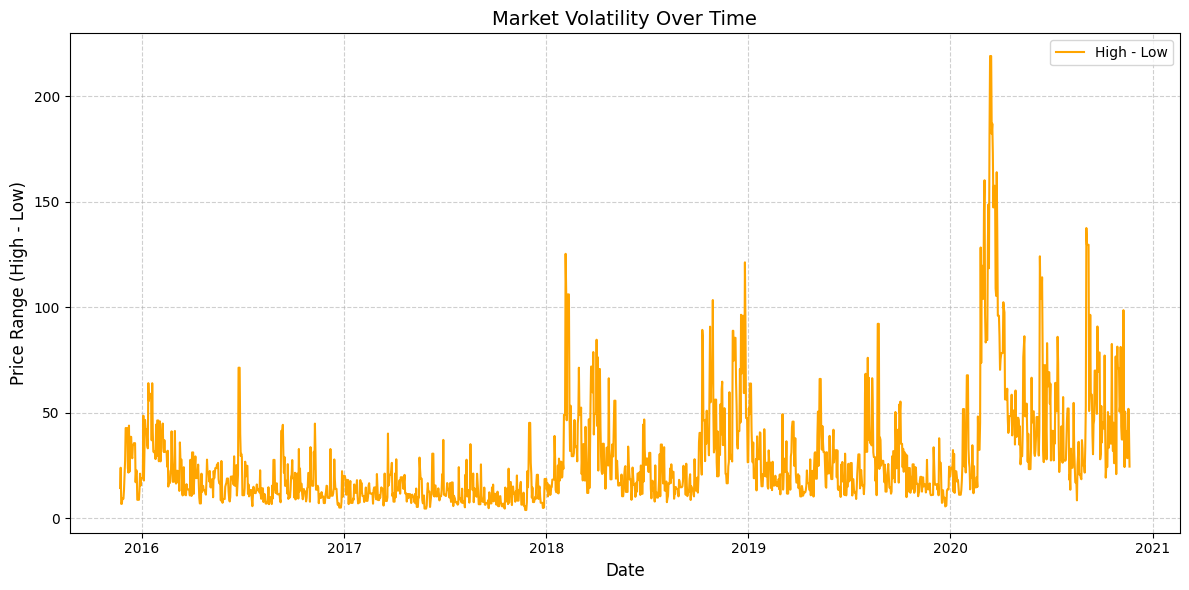

In [32]:
plt.figure(figsize=(12,6))

plt.plot(df2.index, df2["High_Low"],
         color="orange",
         linewidth=1.5,
         label="High - Low")

plt.title("Market Volatility Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price Range (High - Low)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# สร้างตัวแปร Close - Open
df2["Close - Open"] = df2["Close"] - df2["Open"]

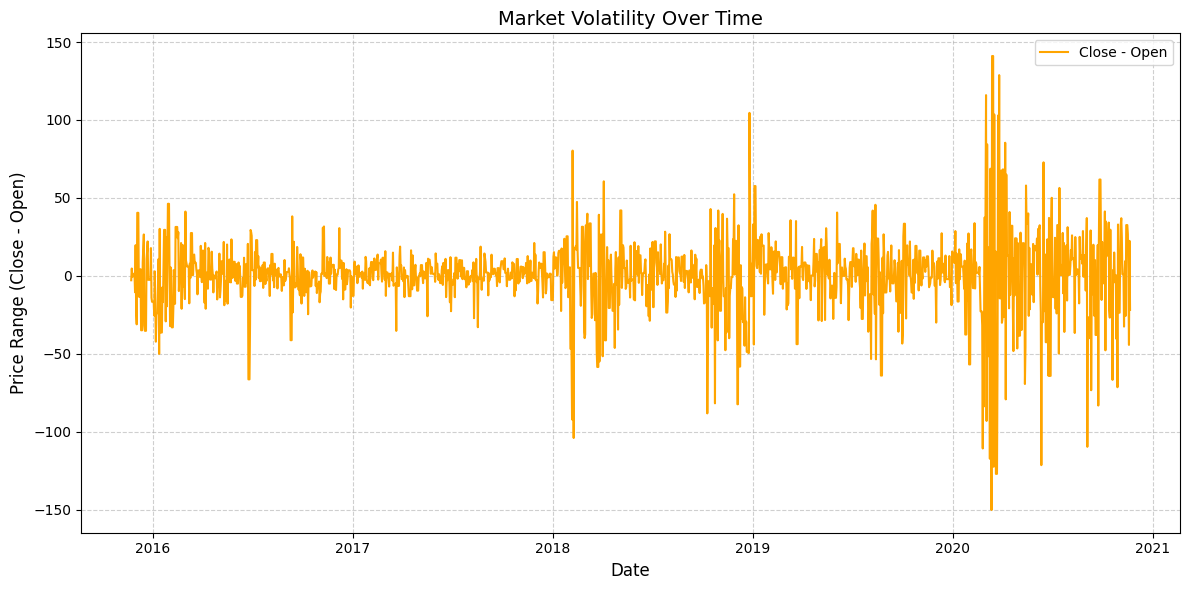

In [34]:
plt.figure(figsize=(12,6))

plt.plot(df2.index, df2["Close - Open"],
         color="orange",
         linewidth=1.5,
         label="Close - Open")

plt.title("Market Volatility Over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price Range (Close - Open)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

In [36]:
import numpy as np

# 1. สร้างตัวแปร "ราคาลง/ขึ้น" (Daily Return)
df2['Daily_Return'] = df2['Adj Close'].pct_change()

# 2. สร้างเส้นค่าเฉลี่ย Volume ย้อนหลัง 20 วัน (เพื่อดูว่า Volume ปกติคือเท่าไหร่)
df2['Avg_Volume_20'] = df2['Volume'].rolling(window=20).mean()

# 3. สร้างตัวแปร "Panic Sell" 
# เงื่อนไข: ราคาตกลงหนักกว่า -3% (0.03) "และ" Volume สูงกว่าค่าเฉลี่ย 1.5 เท่า
df2['Panic_Sell'] = np.where(
    (df2['Daily_Return'] < -0.03) & (df2['Volume'] > df2['Avg_Volume_20'] * 1.5), 
    1, # ถ้าตรงเงื่อนไข ให้ค่าเป็น 1 (เกิด Panic Sell)
    0  # ถ้าไม่ตรง ให้ค่าเป็น 0 (วันปกติ)
)

# 4. ลบข้อมูลที่เป็น NaN ทิ้ง (ผลจากการทำ pct_change และ rolling)
df2 = df2.dropna()